# Proyecto Clasificación de Textos 
## Parte 1: Machine Learning Clásico

Este Jupyter Notebook contiene el flujo de predicción para la competencia de aprendizaje de máquinas para predecir la década a la que pertenece un texto basándonos en los laboratorios de clase.

In [1]:
import pandas as pd
import numpy as np
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import warnings
warnings.filterwarnings("ignore")

import re
import matplotlib.pyplot as plt


### 1. Carga de los Datos
Revisamos los datos brindados en la competencia, `train.csv` y `eval.csv`. Asegúrate de que los archivos se encuentren en el mismo directorio del Notebook.

In [2]:
print("Cargando dataset...")
try:
    df_train = pd.read_csv("./data/train.csv")
    df_eval = pd.read_csv("./data/eval.csv")
    print("Datos cargados. Entrenamos con:", len(df_train), "registros.")
except FileNotFoundError:
    print("Error: Descarga los archivos train.csv y eval.csv acá primero.")


Cargando dataset...
Datos cargados. Entrenamos con: 31403 registros.


### 2. Exploración de datos

No hay datos nulos o vacios, este no va a ser un problema

In [3]:
df_train.isnull().sum()/len(df_train) * 100

text      0.0
decade    0.0
dtype: float64

El formato de las decadas tampoco presenta problemas

In [4]:
df_train["decade"].value_counts()

decade
160    848
172    842
155    836
170    833
167    831
178    831
154    830
157    827
163    827
180    825
168    822
175    817
171    816
165    814
151    812
188    809
179    809
182    808
162    808
174    807
164    804
185    803
184    802
173    802
159    802
181    795
183    794
156    792
161    787
187    787
150    786
152    785
177    782
166    779
158    778
153    775
186    773
169    771
176    754
Name: count, dtype: int64

Para revisar más a fondo los textos, revisaremos qué tantos caracteres extraños hay en cada entrada

In [5]:
patron = r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ0-9\s]"
df_train["ruido"] = df_train["text"].str.count(patron)
df_train["longitud"] = df_train["text"].str.len()
df_train["ratio_ruido"] = df_train["ruido"]/df_train["longitud"]
df_train.head(10)

,text,decade,ruido,longitud,ratio_ruido
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,26,219,0.118721
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19,355,0.053521
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,5,153,0.032680
3,Caistro el M a y o r a i .] Del ape...,163,9,310,0.029032
4,\nlos que panden macho ; y \notros en l...,166,35,1125,0.031111
5,za subitánea di mió fratella. Ah s^egli fosse ...,183,5,175,0.028571
6,\n- 47 — \n— Ídem el capitán de fiaxata ...,184,10,121,0.082645
7,^H^.. vnacopaDemeDioanao(la.©efDccaboDemigiola...,151,39,735,0.053061
8,"Fórmase en cada falda un ancho seno , \n...",184,5,167,0.029940
9,"1 La xxij. h f Defcomulga,con refevuacio.al...",155,18,351,0.051282


In [6]:
df_train.describe()

,decade,ruido,longitud,ratio_ruido
count,31403.000000,31403.000000,31403.000000,31403.000000
mean,168.972614,22.715091,520.568290,0.048763
std,11.222470,23.380435,530.947792,0.031064
min,150.000000,0.000000,120.000000,0.000000
25%,159.000000,8.000000,182.000000,0.030134
50%,169.000000,15.000000,315.000000,0.040984
75%,179.000000,29.000000,643.000000,0.057915
max,188.000000,349.000000,7418.000000,0.566929


In [7]:
bins = [0, 0.1, 0.25, 1]
labels = ["bajo", "medio", "alto"]

df_train["categoria_ruido"] = pd.cut(df_train["ratio_ruido"], bins=bins, labels=labels)
df_train.head(10)

,text,decade,ruido,longitud,ratio_ruido,categoria_ruido
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,26,219,0.118721,medio
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19,355,0.053521,bajo
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,5,153,0.032680,bajo
3,Caistro el M a y o r a i .] Del ape...,163,9,310,0.029032,bajo
4,\nlos que panden macho ; y \notros en l...,166,35,1125,0.031111,bajo
5,za subitánea di mió fratella. Ah s^egli fosse ...,183,5,175,0.028571,bajo
6,\n- 47 — \n— Ídem el capitán de fiaxata ...,184,10,121,0.082645,bajo
7,^H^.. vnacopaDemeDioanao(la.©efDccaboDemigiola...,151,39,735,0.053061,bajo
8,"Fórmase en cada falda un ancho seno , \n...",184,5,167,0.029940,bajo
9,"1 La xxij. h f Defcomulga,con refevuacio.al...",155,18,351,0.051282,bajo


In [8]:
df_train["categoria_ruido"].value_counts()

categoria_ruido
bajo     29608
medio     1709
alto        69
Name: count, dtype: int64

In [9]:
pd.crosstab(df_train["decade"], df_train["categoria_ruido"])

categoria_ruido,bajo,medio,alto
decade,,,
150,750,31,5
151,754,57,1
152,752,30,0
153,669,103,1
154,812,15,1
155,810,25,1
156,759,30,0
157,780,45,1
158,741,36,1


Las clases de la variable objetivo están balanceadas

In [10]:
df_train["decade"].value_counts(normalize=True)

decade
160    0.027004
172    0.026813
155    0.026622
170    0.026526
167    0.026462
178    0.026462
154    0.026431
157    0.026335
163    0.026335
180    0.026271
168    0.026176
175    0.026017
171    0.025985
165    0.025921
151    0.025857
188    0.025762
179    0.025762
182    0.025730
162    0.025730
174    0.025698
164    0.025603
185    0.025571
184    0.025539
173    0.025539
159    0.025539
181    0.025316
183    0.025284
156    0.025221
161    0.025061
187    0.025061
150    0.025029
152    0.024998
177    0.024902
166    0.024807
158    0.024775
153    0.024679
186    0.024615
169    0.024552
176    0.024010
Name: proportion, dtype: float64

### 3. Procesamiento y Limpieza Textual (NLTK)
Siguiendo el laboratorio, utilizaremos tokenización, minúsculas, y truncaremos la palabra con Stemmer.

In [11]:
# Empezamos eliminando los ejemplos para los cuales categoria_ruido es Alta (esto solo se hará para los datos de entrenamiento)

df_train = df_train[df_train["categoria_ruido"]!="alto"]

In [12]:
#nltk.download("punkt")
#nltk.download("punkt_tab")
stemmer = PorterStemmer()

print("Iniciando limpieza textual de Train y Eval...")
# Reemplazamos los signos raros y de puntuación por espacios
# Para el caractér "-" que indica la contuniadad de una pabra el la siguiente línea hacemos una excepción y lo eliminamos
df_train["clean_text"] = df_train["text"].str.replace(r"-\s*\n\s*","",regex=True)
df_train["clean_text"] = df_train["clean_text"].str.replace(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]"," ",regex=True)

df_eval["clean_text"] = df_eval["text"].str.replace(r"-\s*\n\s*","",regex=True)
df_eval["clean_text"] = df_eval["clean_text"].str.replace(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]"," ",regex=True)
# Arreglamos los espacios para que solo quede uno
df_train["clean_text"] = df_train["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()
df_eval["clean_text"] = df_eval["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()


def token_y_stem(text):
    tokens = word_tokenize(str(text).lower())
    return " ".join([stemmer.stem(t) for t in tokens if t.isalnum()])

df_train["clean_text"] = df_train["clean_text"].apply(token_y_stem)
df_eval["clean_text"] = df_eval["clean_text"].apply(token_y_stem)

print("¡Textos procesados!")
df_train.head(3)

Iniciando limpieza textual de Train y Eval...
¡Textos procesados!


,text,decade,ruido,longitud,ratio_ruido,categoria_ruido,clean_text
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,26,219,0.118721,medio,honoraria jubilada dit ad pontem de poreft pro...
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,19,355,0.053521,bajo,gone su amigo su client todo cuanto le rodea l...
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,5,153,0.032680,bajo,prefosen quemanera e per qualesfolpecha deuan ...


In [13]:
df_train["clean_text"][0]

'honoraria jubilada dit ad pontem de poreft proreg m pag ste ph gratian difcept áqu len ne parec que aísilt o ayuda calsiodoro lib epuft s dond llama ocloso cingv y'

### 4. Representación Vectorial (Vectorización TF-IDF)
Usando los conceptos de la clase, se usará `TfidfVectorizer` agregando bigramas y excluyendo stop words.

In [14]:
stopwords_es = ["yo","mi","conmigo","tú","ti","contigo","vos","él","ella","ello","usted","sí","consigo","nosotros","nosotras","ellos",
                "ellas","ustedes","me","te","nos","lo","la","se","los","las","les","mía","mío","míos","mías","tuyo","tuya","tuyos","tuyas",
                "suyo","suya","suyos","suyas","nuestro","nuestra","nuestros","nuestras","este","esta","esto","estos","estas","ese","eso",
                "esa","esos","esas","aquel","aquello","aquella","aquellos","aquellas","uno","una","unos","unas","otro","otra","otros","otras",
                "cualquiera","cualesquiera","quienquiera","quienesquiera","demás","de","que","en","por","con","del","para","como","pues",
                "pero","porque","muy","mas","era","parte","donde","no","ni","ya","es","al","le","su","ha","si","sus","fue","quien","el","entre",
                "un","bien","dos","tu","don","tiempo"]

vectorizador = TfidfVectorizer(max_features=25000, stop_words=stopwords_es, max_df=0.8, ngram_range=(1,3))

print("Construyendo matriz TF-IDF...")
X = vectorizador.fit_transform(df_train["clean_text"])
y = df_train["decade"]
print("Matriz terminada")

# Split local temporal para ver qué tan bueno es
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

Construyendo matriz TF-IDF...
Matriz terminada


In [15]:
doc_vector = X[0].toarray().flatten()

df_importancia = pd.DataFrame({
    "palabra": vectorizador.get_feature_names_out(),
    "peso": doc_vector
})

df_importancia = df_importancia.sort_values(by="peso", ascending=False)

df_importancia.head()

,palabra,peso
18356,poreft,0.384485
17873,ph,0.350855
21736,ste,0.349408
13440,len,0.321765
6665,dit,0.321011


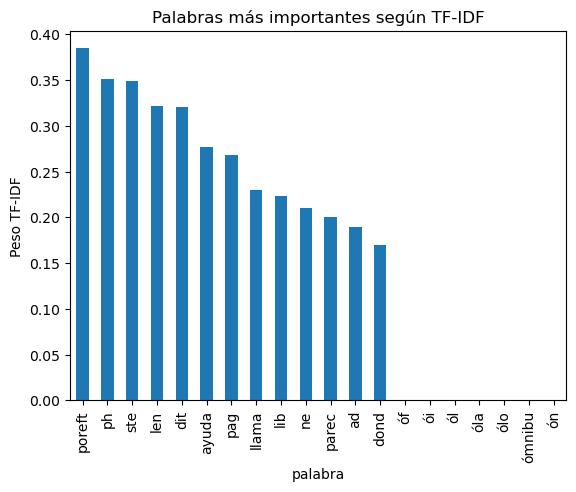

In [16]:
df_importancia.head(20).plot.bar(x="palabra", y="peso", legend=False)

plt.title("Palabras más importantes según TF-IDF")
plt.ylabel("Peso TF-IDF")
plt.show()

### 5. Construcción del Modelo Clásico
Probaremos `SGDClassifier`, que suele dominar entre los sistemas clásicos para NLP (implementa Regresión Lineal/Logística robusta y rápida).

In [17]:
modelo_val = SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, random_state=42)
modelo_val.fit(X_train, y_train)

y_pred_val = modelo_val.predict(X_test)
print("Métricas Locales (Opcional):")
print(classification_report(y_test, y_pred_val))
print("Accuracy Local:", accuracy_score(y_test, y_pred_val))


Métricas Locales (Opcional):
              precision    recall  f1-score   support

         150       0.40      0.75      0.52       124
         151       0.26      0.47      0.34       132
         152       0.46      0.57      0.51       136
         153       0.22      0.39      0.28       118
         154       0.32      0.48      0.38       109
         155       0.20      0.14      0.16       125
         156       0.32      0.40      0.36       120
         157       0.17      0.12      0.14       128
         158       0.23      0.22      0.23       126
         159       0.14      0.28      0.18       109
         160       0.12      0.08      0.10       126
         161       0.15      0.03      0.05       133
         162       0.13      0.14      0.14       114
         163       0.16      0.09      0.11       124
         164       0.09      0.09      0.09       101
         165       0.10      0.06      0.07       124
         166       0.05      0.01      0.01       12

### 6. Predicción Final y Respuesta Kaggle
Ajustamos nuevamente al total de datos para no perder esa información y exportamos.

In [ ]:
modelo_final = SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, random_state=42)
modelo_final.fit(X, y)

print("Realizando predicciones finales...")
X_eval = vectorizador.transform(df_eval["texto_limpio"])
predicciones = modelo_final.predict(X_eval)

df_eval["answer"] = predicciones
submission = df_eval[["id", "answer"]]
submission.to_csv("submission.csv", index=False)
print("¡Archivo guardado como submission.csv! Listo para Kaggle.")


### 7. Guardar el Modelo (Requerimiento de la clase para Bloque Neón)

In [ ]:
print("Guardando modelos usando Joblib...")
joblib.dump(modelo_final, "modelo_clasificador.joblib")
joblib.dump(vectorizador, "vectorizador.joblib")
print("Archivo de modelos guardados (entregables válidos).")
